In [1]:
import cv2
import os
import time
import numpy as np
from ultralytics import YOLO
import matplotlib.pyplot as plt


%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# --- Configuration (Copy these from video_processor.py) ---
YOLO_MODEL_PATH = "yolov8n.pt"

# Bird's-Eye View (BEV) Source Points (from your calibration)
SOURCE_POINTS = [
    (11, 162),  # Top-Left
    (352, 161), # Top-Right
    (357, 325), # Bottom-Right
    (15, 327)   # Bottom-Left
]

# BEV Destination Configuration
DEST_WIDTH_BEV = 341
DEST_HEIGHT_BEV = 166
DEST_POINTS_BEV = [
    (0, 0),
    (DEST_WIDTH_BEV - 1, 0),
    (DEST_WIDTH_BEV - 1, DEST_HEIGHT_BEV - 1),
    (0, DEST_HEIGHT_BEV - 1)
]

# Real-world assumption and BEV scaling
REAL_WORLD_WIDTH_METERS = 5.0 
PIXELS_PER_METER_BEV = DEST_WIDTH_BEV / REAL_WORLD_WIDTH_METERS 

# Video file path (Ensure 'default_queue.mp4' is in the 'uploads' folder relative to the notebook)
VIDEO_FILE_PATH = os.path.join('uploads', 'default_queue.mp4')

print("Configuration loaded:")
print(f"YOLO Model: {YOLO_MODEL_PATH}")
print(f"BEV Source Points: {SOURCE_POINTS}")
print(f"BEV Pixels Per Meter: {PIXELS_PER_METER_BEV:.2f}")
print(f"Video File: {VIDEO_FILE_PATH}")

Configuration loaded:
YOLO Model: yolov8n.pt
BEV Source Points: [(11, 162), (352, 161), (357, 325), (15, 327)]
BEV Pixels Per Meter: 68.20
Video File: uploads\default_queue.mp4


In [3]:
# Load the YOLO model
try:
    model = YOLO(YOLO_MODEL_PATH)
    print(f"YOLO model '{YOLO_MODEL_PATH}' loaded successfully.")
except Exception as e:
    print(f"Error loading YOLO model: {e}")
    # Stop execution if model fails to load
    raise

# Calculate the perspective transformation matrix (M) for BEV
M = cv2.getPerspectiveTransform(np.float32(SOURCE_POINTS), np.float32(DEST_POINTS_BEV))
print("Perspective Transform Matrix (M) calculated.")


YOLO model 'yolov8n.pt' loaded successfully.
Perspective Transform Matrix (M) calculated.


In [ ]:
# Helper function to check if a point is within a defined polygon
def is_in_zone(x, y, zone_polygon):
    """Checks if point (x, y) is inside the zone_polygon."""
    return cv2.pointPolygonTest(np.array(zone_polygon, np.int32), (x, y), False) >= 0

# Helper function to draw detection boxes (simplified for notebook)
def draw_detection_box(frame, x1, y1, x2, y2, class_name, conf):
    """Draws a simple bounding box with label and confidence."""
    color = (0, 255, 0) # Green
    thickness = 2
    cv2.rectangle(frame, (x1, y1), (x2, y2), color, thickness)
    label = f"{class_name}: {conf:.2f}"
    (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 1)
    cv2.rectangle(frame, (x1, y1 - th - 5), (x1 + tw, y1), color, -1)
    cv2.putText(frame, label, (x1, y1 - 4), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 1)

In [1]:
# --- DEBUG CELL ---
import os

# Get the current working directory of the notebook
notebook_dir = os.getcwd()
print(f"Notebook is running in: {notebook_dir}")

# Construct the absolute path to the video
video_abs_path = os.path.abspath(VIDEO_FILE_PATH)
print(f"Trying to open video at: {video_abs_path}")

# Check if the file actually exists at that path
file_exists = os.path.exists(video_abs_path)
print(f"Does the video file exist at that path? {file_exists}")

if not file_exists:
    print("\n⚠️ ERROR: Cannot find the video file. Please check:")
    print("1. Is 'default_queue.mp4' inside an 'uploads' folder?")
    print("2. Is the 'uploads' folder in the same directory as this notebook?")
# --- END DEBUG CELL ---

Notebook is running in: c:\Users\sgrah\OneDrive\Desktop\trail mini project final\yolo-detetction-mini-project\notebooks


NameError: name 'VIDEO_FILE_PATH' is not defined

Successfully read the first frame.


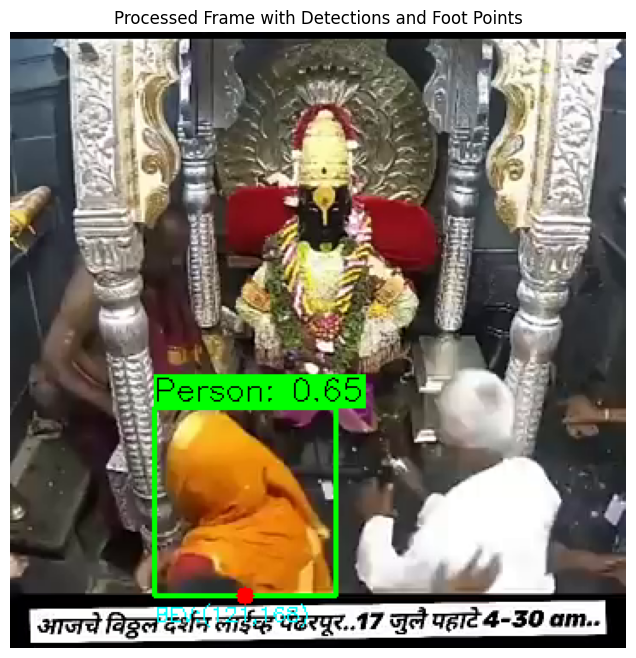


BEV Coordinates of detected people (feet position):
Person 1: (X=120.7, Y=167.7)

Video processing complete.


In [ ]:
# Open the video file
cap = cv2.VideoCapture(VIDEO_FILE_PATH)
if not cap.isOpened():
    print(f"Error opening video file: {VIDEO_FILE_PATH}")
else:
    # Read the first frame
    ret, frame = cap.read()
    if not ret:
        print("Error reading the first frame.")
    else:
        print("Successfully read the first frame.")
        
        # Get frame dimensions for dynamic queue zone check
        frame_height, frame_width = frame.shape[:2]
        margin_x = int(frame_width * 0.1)
        margin_y = int(frame_height * 0.1)
        # Dynamic zone used just to decide IF we process this person
        check_zone = [ 
            (margin_x, margin_y), (frame_width - margin_x, margin_y),
            (frame_width - margin_x, frame_height - margin_y), (margin_x, frame_height - margin_y)
        ]

        # --- Object Detection ---
        results = model(frame, verbose=False) # Run YOLO detection
        
        detected_people_bev_coords = [] # Store BEV coordinates for visualization

        # Process detections
        for result in results:
            for box in result.boxes:
                # Check if it's a person (class ID 0 for COCO)
                if int(box.cls[0]) == 0: 
                    x1, y1, x2, y2 = map(int, box.xyxy[0])
                    cx, cy = (x1 + x2) // 2, (y1 + y2) // 2
                    conf = float(box.conf[0])
                    
                    # Check if the person's center is roughly in our dynamic zone
                    if conf > 0.5 and is_in_zone(cx, cy, check_zone): 
                        
                        # Draw the box on the original frame
                        draw_detection_box(frame, x1, y1, x2, y2, "Person", conf)

                        # --- BEV Transformation ---
                        # Use the bottom-center point (feet) for BEV
                        foot_point = np.array([[[cx, y2]]], dtype=np.float32) 
                        bev_point = cv2.perspectiveTransform(foot_point, M)
                        bev_x, bev_y = bev_point[0][0]
                        detected_people_bev_coords.append((bev_x, bev_y))
                        
                        # Add a small circle at the foot point in the original image
                        cv2.circle(frame, (cx, y2), 5, (0, 0, 255), -1) # Red dot at foot point
                        
                        # (Optional) Add text showing BEV coordinates near the box
                        cv2.putText(frame, f"BEV:({bev_x:.0f},{bev_y:.0f})", (x1, y2 + 15), 
                                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 0), 1)

        # --- Display the Processed Frame ---
        # Convert frame from BGR (OpenCV default) to RGB (Matplotlib default)
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        
        plt.figure(figsize=(12, 8))
        plt.imshow(frame_rgb)
        plt.title("Processed Frame with Detections and Foot Points")
        plt.axis('off') # Hide axes
        plt.show()

        print("\nBEV Coordinates of detected people (feet position):")
        for i, (bx, by) in enumerate(detected_people_bev_coords):
             print(f"Person {i+1}: (X={bx:.1f}, Y={by:.1f})")

    # Release the video capture object
    cap.release()
    print("\nVideo processing complete.")